In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv(
    "../data/processed/cleaned_stray_animal_reports.csv"
)

df.head()

,Report_ID,Animal_Type,Breed,Age,Gender,Health_Status,Location,Reported_Date,Rescue_Status
0,1,Dog,Beagle,5,Male,Healthy,Negombo,2026-01-13,Rescued
1,2,Dog,Labrador,15,Female,Healthy,Galle,2026-01-28,Rescued
2,3,Cat,Domestic Short Hair,5,Male,Healthy,Colombo,2026-05-22,Rescued
3,4,Dog,Golden Retriever,1,Male,Critical,Jaffna,2026-04-29,Released
4,5,Dog,Beagle,5,Male,Sick,Colombo,2026-01-27,Under Treatment


In [3]:
X = df[
    [
        "Animal_Type",
        "Breed",
        "Age",
        "Gender",
        "Location"
    ]
]

y = df["Health_Status"]

In [4]:
print("X shape:", X.shape)
print("Y shape:", y.shape)

print("\nTarget classes:")
print(y.value_counts())

X shape: (1000, 5)
Y shape: (1000,)

Target classes:
Health_Status
Sick        278
Injured     248
Healthy     239
Critical    235
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 5)
Testing data: (200, 5)


In [6]:
categorical_features = [
    "Animal_Type",
    "Breed",
    "Gender",
    "Location"
]

numeric_features = [
    "Age"
]

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                random_state=42
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_predictions = rf_pipeline.predict(X_test)

In [9]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=8,
                random_state=42
            )
        )
    ]
)

dt_pipeline.fit(X_train, y_train)

dt_predictions = dt_pipeline.predict(X_test)

In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            KNeighborsClassifier(n_neighbors=5)
        )
    ]
)

knn_pipeline.fit(X_train, y_train)

knn_predictions = knn_pipeline.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, rf_predictions)
dt_accuracy = accuracy_score(y_test, dt_predictions)
knn_accuracy = accuracy_score(y_test, knn_predictions)

print("Random Forest Accuracy:", rf_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
print("KNN Accuracy:", knn_accuracy)

Random Forest Accuracy: 0.24
Decision Tree Accuracy: 0.235
KNN Accuracy: 0.25


In [12]:
print(
    classification_report(
        y_test,
        rf_predictions
    )
)

              precision    recall  f1-score   support

    Critical       0.27      0.28      0.27        47
     Healthy       0.24      0.23      0.23        48
     Injured       0.21      0.24      0.23        50
        Sick       0.24      0.22      0.23        55

    accuracy                           0.24       200
   macro avg       0.24      0.24      0.24       200
weighted avg       0.24      0.24      0.24       200



NameError: name 'plt' is not defined

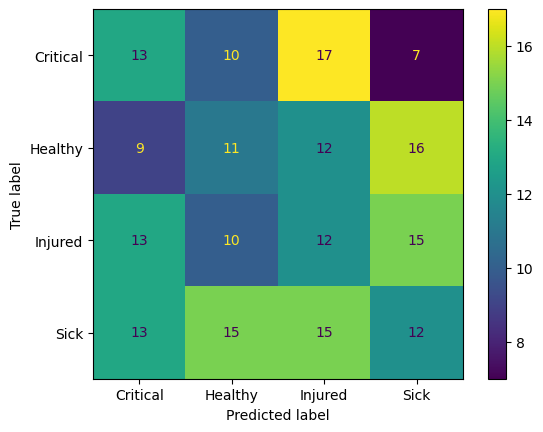

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions
)

plt.title("Random Forest - Health Status Confusion Matrix")
plt.show()

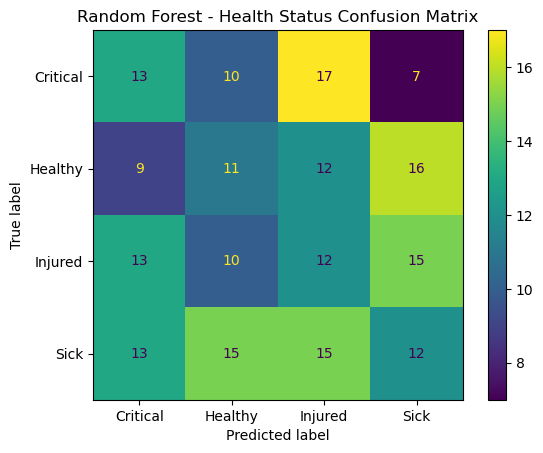

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions
)

plt.title("Random Forest - Health Status Confusion Matrix")
plt.show()

In [15]:
import joblib

joblib.dump(
    rf_pipeline,
    "../models/health_status_model.joblib"
)

['../models/health_status_model.joblib']